# Reddit Cleaning Validation

This notebook validates the cleaned Reddit datasets produced by `reddit_cleaning.ipynb`.

Dataset = the two parquet files in `data/cleaned/`. The raw files in `data/processed/combined/` are only used for before/after row counts.

In [1]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.parquet as pq
import matplotlib.ticker as mtick

ROOT = Path.cwd()

while not (ROOT / "data").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if not (ROOT / "data").is_dir():
    raise FileNotFoundError("Project root with data/ directory was not found.")

DATA = ROOT / "data"
CLEANED = DATA / "cleaned"
RAW = DATA / "processed" / "combined"

FILES = {"submissions": CLEANED / "submissions_clean.parquet","comments": CLEANED / "comments_clean.parquet",}
RAW_FILES = {"submissions": RAW / "submissions_trump.parquet","comments": RAW / "comments_trump.parquet",}

files = {k: pq.ParquetFile(p) for k, p in FILES.items()}
raw_md = {k: pq.ParquetFile(p).metadata for k, p in RAW_FILES.items()}

## size, rows, breakdown by type

In [2]:
overview = pd.DataFrame(
    {
        "size_MB": [FILES[k].stat().st_size / 1024**2 for k in files],
        "rows": [f.metadata.num_rows for f in files.values()],
        "rows_raw": [raw_md[k].num_rows for k in files],
        "columns": [f.metadata.num_columns for f in files.values()],
        "columns_raw": [raw_md[k].num_columns for k in files],
    },
    index=list(files),
)
overview["rows_%"] = 100 * overview["rows"] / overview["rows"].sum()
overview.loc["TOTAL"] = overview.sum()
overview["rows_removed_%"] = 100 * (1 - overview["rows"] / overview["rows_raw"])
overview.round(1)

,size_MB,rows,rows_raw,columns,columns_raw,rows_%,rows_removed_%
submissions,125.2,497211.0,513848.0,32.0,132.0,9.9,3.2
comments,2045.5,4514780.0,4601620.0,22.0,87.0,90.1,1.9
TOTAL,2170.7,5011991.0,5115468.0,54.0,219.0,100.0,2.0


## Estimating csv size

In [3]:
def est_pandas_gb(name, batch=20_000, n_samples=24):
    f = files[name]
    if f.metadata.num_row_groups >= n_samples:
        # one batch from the start of every row group so different periods are sampled
        batches = (next(f.iter_batches(batch_size=batch, row_groups=[i])) for i in range(f.metadata.num_row_groups))
    else:
        # few row groups (submissions = 1) -> take every k-th batch across the file instead
        step = max(1, -(-f.metadata.num_rows // batch) // n_samples)
        batches = (b for i, b in enumerate(f.iter_batches(batch_size=batch)) if i % step == 0)
    sample = pd.concat(b.to_pandas() for b in batches)
    per_row = sample.memory_usage(deep=True).sum() / len(sample)
    return {"sample_rows": len(sample), "bytes_per_row": per_row,
            "est_pandas_GB": per_row * f.metadata.num_rows / 1024**3}


est = pd.DataFrame({k: est_pandas_gb(k) for k in files}).T
est.loc["TOTAL", "est_pandas_GB"] = est["est_pandas_GB"].sum()
est.round(2)

,sample_rows,bytes_per_row,est_pandas_GB
submissions,497211.0,1382.64,0.64
comments,461601.0,1542.94,6.49
TOTAL,NaN,NaN,7.13


## counts per category

Categorical columns present in both files: `subreddit`, `source_month` and (new after cleaning) `period`.
Counted row-group by row-group so the 2 GB comments file never lands in RAM at once.

In [4]:
def count_by(name, column):
    f = files[name]
    counts = Counter()
    for i in range(f.metadata.num_row_groups):
        counts.update(f.read_row_group(i, columns=[column])[column].to_pylist())
    return pd.Series(counts, name=name).sort_values(ascending=False)


by_month = pd.concat([count_by(k, "source_month") for k in files], axis=1).sort_index()
by_month.style.format("{:,}").background_gradient(cmap="Blues")

,submissions,comments
2017-01,"37,741","372,120"
2017-02,"36,800","315,056"
2017-03,"32,524","285,084"
2017-04,"25,004","199,660"
2017-05,"33,913","291,848"
2017-06,"26,054","259,322"
2018-01,"28,408","251,397"
2018-02,"22,558","192,821"
2018-03,"26,229","220,215"
2018-04,"23,431","212,159"


distinct subreddits: 6


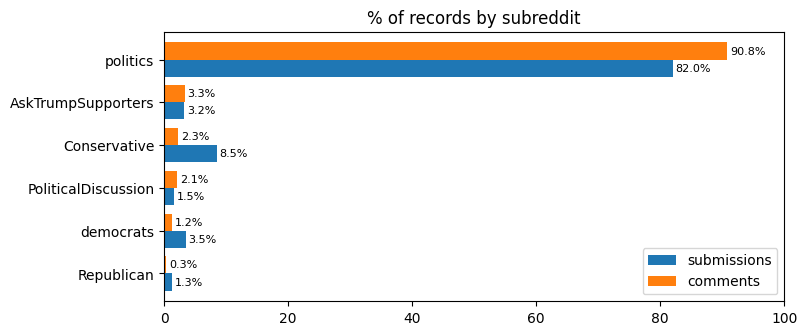

In [5]:
by_sub = pd.concat([count_by(k, "subreddit") for k in files], axis=1).fillna(0).astype(int)
print(f"distinct subreddits: {len(by_sub):,}")
share = 100 * by_sub / by_sub.sum()
ax = share.sort_values("comments").plot.barh(figsize=(8, 3.5), width=0.8, xlim=(0, 100), title="% of records by subreddit")
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=8)

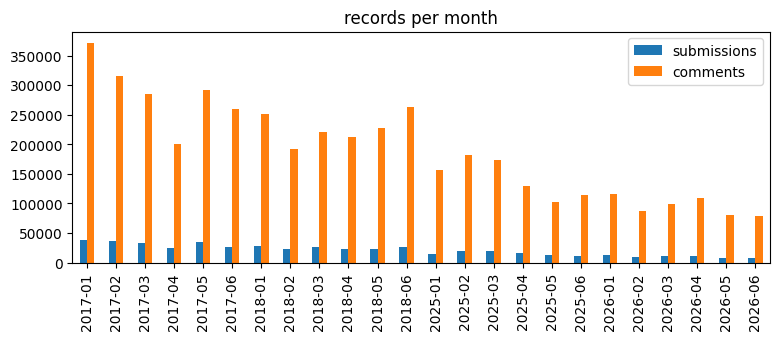

In [6]:
by_month.plot.bar(figsize=(9, 3), title="records per month");

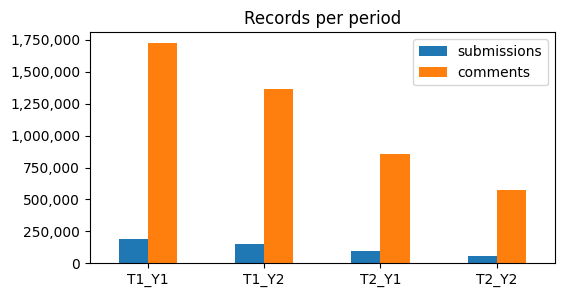

In [7]:
# period = first / second year of each Trump term (T1 = 2017-2018, T2 = 2025-2026)
by_period = pd.concat([count_by(k, "period") for k in files], axis=1).sort_index()
ax = by_period.plot.bar(figsize=(6, 3),rot=0,title="Records per period")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

## duplicates

Reddit `id` is unique per comment / per submission, so a repeated id = same record collected twice. Only the `id` column is read.

In [8]:
def dup_check(name):
    ids = files[name].read(columns=["id"])["id"]
    valid = len(ids) - ids.null_count
    return {"rows": len(ids), "null_ids": ids.null_count, "duplicate_rows": valid - pc.count_distinct(ids).as_py()}


pd.DataFrame({k: dup_check(k) for k in files}).T

,rows,null_ids,duplicate_rows
submissions,497211,0,0
comments,4514780,0,0


## head

FFirst 3 rows, transposed (32 submission / 22 comment columns). Note: rows are sorted by time, so the first rows are all 2017-01.

In [9]:
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", 60):
    for k, f in files.items():
        print(k)
        display(next(f.iter_batches(batch_size=3)).to_pandas().T)

submissions


,0,1,2
id,5lch1i,5lci8r,5lciy3
created_utc,1483228990,1483229424,1483229651
source_month,2017-01,2017-01,2017-01
subreddit,politics,politics,politics
author,Gaybro1992,gazil9,[deleted]
author_flair_text,<NA>,<NA>,<NA>
title,Trump ditches press pool to play golf,"Putin won 2016, but Russia has its limits as a superpower​","This Photo of a Trump Billboard in Mumbai is Real, and s..."
selftext,,,
is_self,False,False,False
domain,cnn.com,washingtonpost.com,m.huffpost.com


comments


,0,1,2
id,dbumnwy,dbumos7,dbumotn
submission_id,5lbx9q,5lbdw1,5lbx9q
parent_id,t3_5lbx9q,t1_dbufh70,t1_dbule2l
created_utc,1483228808,1483228848,1483228850
source_month,2017-01,2017-01,2017-01
subreddit,politics,politics,politics
author,GaryRuppert,Kichigai,GaryRuppert
author_flair_text,America,Minnesota,America
body,Kind of a shame for Bill Clinton that he's determined to...,"Please, McCain has done more to try and unite the countr...",remember when Dems said Trump had no GOTV operation?
score,4,7,0


## dtypes

In [10]:
files["submissions"].schema_arrow.empty_table().to_pandas().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   id                         0 non-null      object             
 1   created_utc                0 non-null      int64              
 2   source_month               0 non-null      object             
 3   subreddit                  0 non-null      object             
 4   author                     0 non-null      object             
 5   author_flair_text          0 non-null      string             
 6   title                      0 non-null      object             
 7   selftext                   0 non-null      object             
 8   is_self                    0 non-null      boolean            
 9   domain                     0 non-null      object             
 10  url                        0 non-null      object             
 11  link_flair_text   

In [11]:
files["comments"].schema_arrow.empty_table().to_pandas().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   id                   0 non-null      string             
 1   submission_id        0 non-null      string             
 2   parent_id            0 non-null      string             
 3   created_utc          0 non-null      int64              
 4   source_month         0 non-null      string             
 5   subreddit            0 non-null      string             
 6   author               0 non-null      string             
 7   author_flair_text    0 non-null      string             
 8   body                 0 non-null      string             
 9   score                0 non-null      int32              
 10  controversiality     0 non-null      int8               
 11  stickied             0 non-null      boolean            
 12  edited               0 non-null   

## missing values

Null counts straight from the parquet footer (no data read). NaN in the table = column not in that file.

In [12]:
def null_counts(name):
    f = files[name]
    md = f.metadata
    out = {}
    for j in range(md.num_columns):
        stats = [md.row_group(i).column(j).statistics for i in range(md.num_row_groups)]
        c = md.schema.column(j).name
        if all(s is not None and s.has_null_count for s in stats):
            out[c] = sum(s.null_count for s in stats)
        else:  # no footer stats (all-null columns) -> read it, cheap
            out[c] = f.read(columns=[c])[c].null_count
    s = pd.Series(out)
    return pd.DataFrame({"nulls": s, "null_%": (100 * s / md.num_rows).round(1)})


nulls = pd.concat({k: null_counts(k) for k in files}, axis=1)
all_null = {k: nulls.index[nulls[(k, "nulls")] == files[k].metadata.num_rows].tolist() for k in files}
for k, cols in all_null.items():
    print(f"{k}: {len(cols)} columns 100% null:", cols)
with pd.option_context("display.max_rows", None):
    display(nulls[(nulls.xs("null_%", axis=1, level=1) > 0).any(axis=1)].sort_values(("comments", "null_%")))

submissions: 0 columns 100% null: []
comments: 0 columns 100% null: []


submissions          comments       
                          nulls null_%      nulls null_%
author_flair_text      394077.0   79.3  3686989.0   81.7
stance                 485239.0   97.6  4370148.0   96.8
link_flair_text        264888.0   53.3        NaN    NaN
upvote_ratio           342371.0   68.9        NaN    NaN
removed_by_category    454572.0   91.4        NaN    NaN

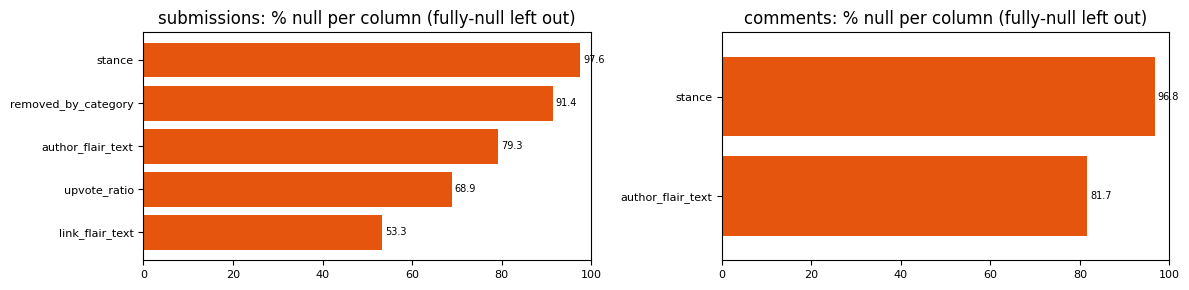

In [13]:
partial = {k: nulls[(k, "null_%")].drop(all_null[k]).dropna().loc[lambda s: s > 0].sort_values() for k in files}
fig, axes = plt.subplots(1, 2, figsize=(12, 0.3 * max(len(s) for s in partial.values()) + 1.5))
for ax, (k, s) in zip(axes, partial.items()):
    if s.empty:
        ax.set_title(f"{k}: no partially-null columns")
        continue
    s.plot.barh(ax=ax, width=0.8, xlim=(0, 100), color="#e6550d", fontsize=8,
                title=f"{k}: % null per column (fully-null left out)")
    ax.bar_label(ax.containers[0], fmt="%.1f", padding=2, fontsize=7)
fig.tight_layout()

In [14]:
# nulls come in whole-month blocks (field missing from that period's dump) -> % null per month
# red = missing, white = present; rows sorted so columns with the same gap pattern sit together
def null_pct_by_month(name, cols):
    f = files[name]
    month = f.read(columns=["source_month"])["source_month"].to_pandas()
    df = pd.DataFrame({c: f.read(columns=[c])[c].is_null().to_pandas().groupby(month).mean() * 100 for c in cols}).T.round().astype(int)
    return df.sort_values(list(df.columns))


for k in files:
    cols = nulls.index[(nulls[(k, "nulls")] > 0) & (nulls[(k, "nulls")] < files[k].metadata.num_rows)]
    print(k)
    display(null_pct_by_month(k, cols).style.background_gradient(cmap="Reds", vmin=0, vmax=100, axis=None)
            .set_table_styles([{"selector": "td, th", "props": "font-size: 9px; padding: 1px 4px"}]))

submissions


source_month,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
link_flair_text,58,64,64,61,64,57,72,73,70,73,72,75,36,36,36,38,38,38,5,5,4,4,4,4
author_flair_text,86,85,86,83,82,83,82,81,82,100,100,78,69,72,71,68,64,62,63,63,63,61,60,58
stance,96,96,99,97,97,98,98,98,98,100,100,98,97,97,97,97,98,98,97,97,97,97,97,97
upvote_ratio,100,100,100,100,100,100,100,100,100,100,100,100,0,0,0,0,0,0,0,0,0,0,0,0
removed_by_category,100,100,100,100,100,100,100,100,100,100,100,100,65,64,68,70,75,74,74,77,79,79,82,84


comments


source_month,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
author_flair_text,86,84,85,83,82,81,80,81,79,79,78,80,83,83,82,81,81,81,81,82,80,81,79,80
stance,96,95,97,97,97,97,97,98,98,98,96,96,98,97,97,97,98,99,97,97,96,97,96,97


### pseudo-missing

Some missing-like values are intentionally preserved or transformed:

- `[deleted]` authors are retained because the corresponding text may still be available;
- `[deleted]` and `[removed]` in submission `selftext` are replaced with `""`,
  while their original state is stored in `selftext_deleted` and `selftext_removed`;
- some submission titles/texts may be empty because unusable-title threads are retained
  when they are needed as parents of surviving comments;
- `body_clean` should never be empty because comments that become empty after text cleaning are removed.

In [15]:
PSEUDO_VALUES = ["", "nan", "None", "NaN", "[deleted]", "[removed]"]


def pseudo_shares(name, column):
    # streamed per row group: body / body_clean are too big to read at once
    f = files[name]
    counts = Counter()
    for i in range(f.metadata.num_row_groups):
        col = f.read_row_group(i, columns=[column])[column]
        hits = col.filter(pc.is_in(col, value_set=pa.array(PSEUDO_VALUES, type=col.type)))
        counts.update({v["values"]: v["counts"] for v in pc.value_counts(hits).to_pylist()})
    return {v: 100 * n / f.metadata.num_rows for v, n in counts.items()}


pseudo = {(k, c): pseudo_shares(k, c)
          for k, cols in {"submissions": ["author", "title", "selftext", "text", "text_clean"], "comments": ["author", "body", "body_clean"]}.items()
          for c in cols}
print("% of rows")
(pd.DataFrame(pseudo).T.reindex(columns=PSEUDO_VALUES).fillna(0).rename(columns={"": "<empty>"})
 .style.format("{:.1f}").background_gradient(cmap="Oranges", vmin=0, axis=None))

% of rows


## cleaning flags per month

`quarantine` and `pinned` (the mixed float/string columns checked in v3) were dropped during cleaning.
Instead: the boolean flags of the cleaned tables, % True per month.

In [16]:
FLAGS = {
    "submissions": ["selftext_deleted","selftext_removed","author_deleted","title_unusable","is_mod_or_bot_post","submission_mentions_trump",
                    "has_trump_comment","in_scope","is_self","stickied",],
    "comments": ["author_deleted","trump_only_in_quote","is_top_level","edited","stickied",],
}


def flag_pct_by_month(name, cols):
    t = files[name].read(columns=["source_month", *cols]).to_pandas()
    t[cols] = t[cols].astype("boolean")  # nullable: mean() skips missing values
    return 100 * t.groupby("source_month")[cols].mean().astype(float)


pd.concat({k: flag_pct_by_month(k, cols) for k, cols in FLAGS.items()}, axis=1).style.format("{:.1f}").background_gradient(cmap="Greens", axis=None)

## other low-cardinality columns

Full scan: every column with ≤5 distinct values.
Each bar = one column, split into False-like (`False`, `0`, `0.0`), True-like (`True`, `1`, `1.0`), other values and null.
!! = not stored as `bool` but holds only True/False-like values → should be cast to bool (expected: none left after cleaning).

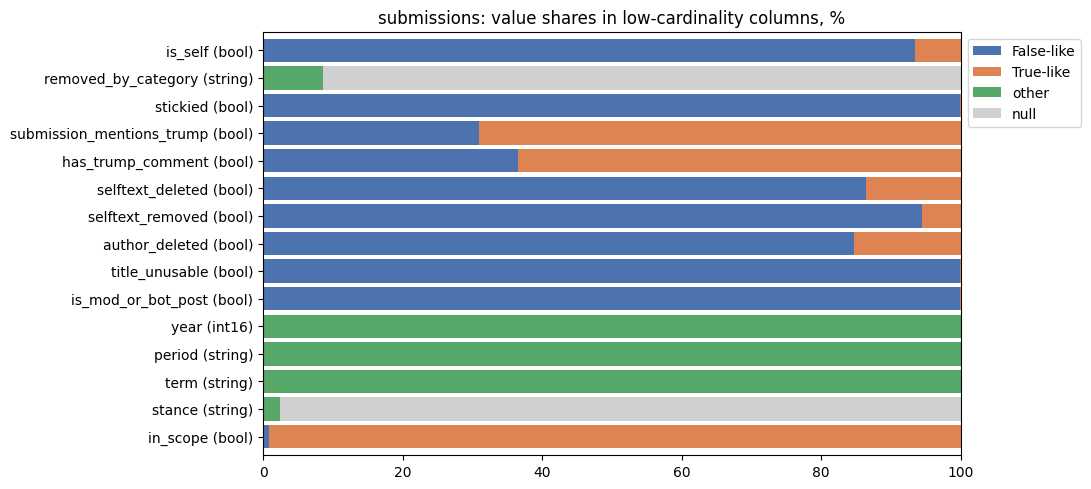

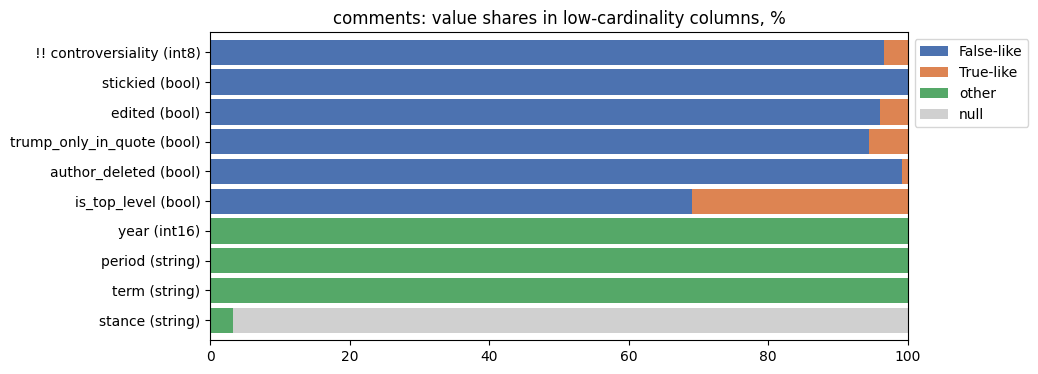

In [17]:
FALSE_LIKE, TRUE_LIKE = {"False", "false", "0", "0.0"}, {"True", "true", "1", "1.0"}
COLORS = {"False-like": "#4c72b0", "True-like": "#dd8452", "other": "#55a868", "null": "#d0d0d0"}


def kind(v):
    return "null" if v is None else "False-like" if str(v) in FALSE_LIKE else "True-like" if str(v) in TRUE_LIKE else "other"


def value_shares(name, max_mb=100, max_distinct=5):
    md = files[name].metadata
    rows = {}
    for j in range(md.num_columns):
        c = md.schema.column(j).name
        # skip heavy text columns (body, text, url) — never low-cardinality anyway
        if sum(md.row_group(i).column(j).total_uncompressed_size for i in range(md.num_row_groups)) > max_mb * 1024**2:
            continue
        col = files[name].read(columns=[c])[c]
        if pa.types.is_null(col.type) or pc.count_distinct(col).as_py() > max_distinct:
            continue
        vc = pc.value_counts(col).to_pylist()
        s = pd.Series([v["counts"] for v in vc], index=[kind(v["values"]) for v in vc]).groupby(level=0).sum()
        warn = "!! " if not pa.types.is_boolean(col.type) and set(s.index) - {"null"} and set(s.index) - {"null"} <= {"False-like", "True-like"} else ""
        rows[f"{warn}{c} ({col.type})"] = 100 * s / s.sum()
    return pd.DataFrame(rows).T.reindex(columns=list(COLORS)).fillna(0)


for k in files:
    shares = value_shares(k).iloc[::-1]  # barh draws bottom-up; keep schema order top-down
    shares.plot.barh(stacked=True, color=COLORS, width=0.85, figsize=(9, 0.3 * len(shares) + 1), xlim=(0, 100),
                     title=f"{k}: value shares in low-cardinality columns, %").legend(loc="upper left", bbox_to_anchor=(1, 1))

## Referential integrity

In [32]:
clean_submission_ids = set(files["submissions"].read(columns=["id"])["id"].to_pylist())
raw_submission_ids = set(pq.ParquetFile(RAW_FILES["submissions"]).read(columns=["id"])["id"].to_pylist())

missing_parent_ids = set()
orphan_comments = 0

comments_file = files["comments"]

for i in range(comments_file.metadata.num_row_groups):
    ids = comments_file.read_row_group(i,columns=["submission_id"])["submission_id"].to_pylist()

    missing = [submission_id for submission_id in ids if submission_id not in clean_submission_ids]

    orphan_comments += len(missing)
    missing_parent_ids.update(missing)

print(f"Comments without a parent submission: {orphan_comments:,}")
print(f"Distinct missing parent submissions: {len(missing_parent_ids):,}")

missing_that_existed_before_cleaning = (missing_parent_ids & raw_submission_ids)
missing_already_in_input = (missing_parent_ids - raw_submission_ids)

print("Missing parents that existed before cleaning:",len(missing_that_existed_before_cleaning))

print("Missing parents already absent before cleaning:",len(missing_already_in_input))

Comments without a parent submission: 9,024
Distinct missing parent submissions: 1,952
Missing parents that existed before cleaning: 0
Missing parents already absent before cleaning: 1952


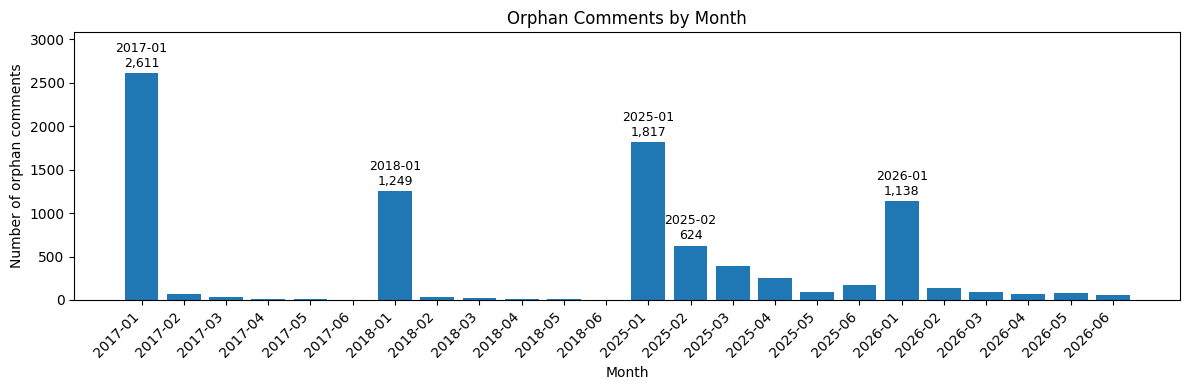

In [29]:
parts = []

for i in range(comments_file.metadata.num_row_groups):
    batch = comments_file.read_row_group(i,columns=["submission_id","source_month","period","subreddit",]).to_pandas()

    orphan = batch["submission_id"].isin(missing_parent_ids)

    if orphan.any():
        parts.append(batch.loc[orphan])

orphans = pd.concat(parts, ignore_index=True)

orphans_by_month = orphans.groupby("source_month").size().sort_index()

plot_data = orphans_by_month.reset_index(name="orphan_comments")

fig, ax = plt.subplots(figsize=(12, 4))

bars = ax.bar(plot_data["source_month"],plot_data["orphan_comments"])

ax.set_title("Orphan Comments by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of orphan comments")

ax.set_xticks(range(len(plot_data)))
ax.set_xticklabels(plot_data["source_month"],rotation=45,ha="right")
ax.set_ylim(0,plot_data["orphan_comments"].max() * 1.18
           )
for i, value in enumerate(plot_data["orphan_comments"]):
    if value > 500:
        ax.text(i,value + 40,f'{plot_data.loc[i, "source_month"]}\n{value:,}',ha="center",va="bottom",fontsize=9)

plt.tight_layout()
plt.show()

The missing-parent comments are concentrated in the first month of each collection window.

Comments posted in January may belong to submission threads created in December of the previous year, while those December submission dumps are outside the selected six-month windows.

Importantly, none of the missing parent submissions were removed during the cleaning step. All 1952 missing submission IDs were already absent from the pre-cleaning submissions dataset. So this is a boundary effect of the collection windows rather than an error introduced by the cleaning pipeline.

## Summary

- **Rows and schema:** 497,211 submissions and 4,514,780 comments remain after cleaning. This corresponds to a 3.2% reduction in submissions and a 1.9% reduction in comments. The schema was reduced from 132 to 32 submission columns and from 87 to 22 comment columns.
- **Duplicates:** no duplicate or null `id`s in either file.
- **Volume:** falls from 2017 to 2026 (comments T1_Y1 1.72M → T2_Y2 0.57M). r/politics is still ~90% of comments, so compare shares rather than raw counts.
- **Missing values:** no fully-null columns remain. Missingness is concentrated in metadata fields rather than core text or identifiers:
  - `author_flair_text`: 79.3% null in submissions and 81.7% in comments;
  - `stance`: 97.6% / 96.8% null because it is mainly available for r/AskTrumpSupporters;
  - `link_flair_text`: 53.3% null in submissions;
  - `upvote_ratio`: 68.9% null overall and completely unavailable in the 2017–2018 dumps;
  - `removed_by_category`: 91.4% null overall and also unavailable in 2017–2018;
  - submission `author_flair_text` is completely missing in 2018-04 and 2018-05, indicating a dump-level data gap rather than a cleaning error.
- **Pseudo-missing:** Reddit placeholders such as `[deleted]` and `[removed]` were handled explicitly. Deleted/removed submission text is replaced in the cleaned text fields while the original state is preserved through flags such as `selftext_deleted` and `selftext_removed`. Deleted authors are retained through `author_deleted` because their associated text may still be available.
- **Cleaning flags:** the cleaned submissions retain explicit indicators for unusable titles, moderator/bot posts, Trump mentions, Trump-related comments, and analytical scope (`in_scope`). Comments retain structural and cleaning-related flags such as `author_deleted`, `trump_only_in_quote`, `is_top_level`, `edited`, and `stickied`.
- **Referential integrity:** 9,024 comments reference 1,952 unique parent submissions that are unavailable in the submissions dataset. None of these parent submissions were removed during cleaning. All 1,952 were already absent from the pre-cleaning input. The missing-parent comments are concentrated at the beginning of the collection windows, which is consistent with comments referring to threads created before the downloaded time periods.
- **Dtypes:** no bool-like columns stored as strings or floats remain.